In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Front_End/static/chart/api/education_data/PISA.csv")

print('Kolom yang tersedia:')
print(df)
print(df.columns.tolist())

plt.figure(figsize=(10, 6))
df_sorted = df.sort_values(by='x_maths', ascending=False)
plt.bar(df_sorted['Category'], df_sorted['x_maths'], color='skyblue', label='Matematika')
plt.bar(df_sorted['Category'], df_sorted['x_reading'], alpha=0.7, color='orange', label='Membaca')
plt.bar(df_sorted['Category'], df_sorted['x_scie'], alpha=0.6, color='green', label='Sains')
plt.title("Skor PISA per Negara")
plt.xlabel("Negara")
plt.ylabel("Skor")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
output_path = "Front_End/static/chart/api/education_data/PISA_visualisasi.png"
plt.savefig(output_path)
print(f"✅ Grafik berhasil disimpan di: {output_path}")



Kolom yang tersedia:
                                                                                                             Indonesia
Category dot_nsig  Mean performance line      Best-fitting trend x_maths x_reading x_scie  OECD Average (23 countries)
2000     NaN       NaN              NaN       NaN                NaN     NaN       NaN                       499.53403
2000.5   NaN       NaN              NaN       NaN                NaN     NaN       NaN                         499.181
                                                                                   NaN                             NaN
2000.25  NaN       NaN              NaN       NaN                NaN     NaN       NaN                       499.35751
...                                                                                                                ...
2021.75  NaN       NaN              366.34671 367.3912           NaN     NaN       NaN                         481.293
                           

KeyError: 'x_maths'

<Figure size 1000x600 with 0 Axes>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Baca file mentah
raw_df = pd.read_csv("Front_End/static/chart/api/education_data/PISA.csv", encoding='utf-8-sig')

# Jika hanya 1 kolom (misalnya 'Indonesia'), kita ekstrak manual
if len(raw_df.columns) == 1:
    col_name = raw_df.columns[0]
    print(f"⚠ Hanya satu kolom ditemukan: {col_name} — mencoba parsing ulang...")

    # Ambil semua baris non-empty
    lines = [str(x) for x in raw_df[col_name].dropna() if str(x).strip() != ""]

    # Pisahkan berdasarkan koma
    split_lines = [re.split(r',+', line) for line in lines]

    # Buat DataFrame baru
    df = pd.DataFrame(split_lines)

    # Baris pertama sering kali header
    df.columns = df.iloc[0]
    df = df.drop(0).reset_index(drop=True)

    print("\n✅ Kolom berhasil dipecah:")
    print(df.columns.tolist())

else:
    df = raw_df.copy()

# Coba konversi angka
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors='ignore')

print("\n=== Data Awal (5 Baris Pertama) ===")
print(df.head())

# --- Cari kolom utama ---
possible_x = [c for c in df.columns if re.search(r'(cat|year|tahun)', str(c), re.I)]
category_col = possible_x[0] if possible_x else df.columns[0]

# Cari kolom yang mengandung skor
score_cols = [c for c in df.columns if re.search(r'(math|read|scie)', str(c), re.I)]

if not score_cols:
    raise ValueError("❌ Tidak ditemukan kolom skor seperti x_maths, x_reading, atau x_scie.")

# --- VISUALISASI ---
plt.figure(figsize=(10, 6))
for col in score_cols:
    plt.plot(df[category_col], pd.to_numeric(df[col], errors='coerce'), marker='o', label=col)

plt.title("📊 Tren Skor PISA (Matematika, Membaca, Sains)")
plt.xlabel(category_col)
plt.ylabel("Skor")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Simpan
output_path = "Front_End/static/chart/api/education_data/PISA_visualisasi.png"
plt.savefig(output_path)
print(f"✅ Grafik berhasil disimpan di: {output_path}")


⚠ Hanya satu kolom ditemukan: Indonesia — mencoba parsing ulang...

✅ Kolom berhasil dipecah:
['OECD Average (23 countries)']

=== Data Awal (5 Baris Pertama) ===
0  OECD Average (23 countries)
0                    499.53403
1                    499.18100
2                    499.35751
3                    499.00446
4                    498.82794


C:\Users\acer\AppData\Local\Temp\ipykernel_15584\1978452607.py:34: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


ValueError: ❌ Tidak ditemukan kolom skor seperti x_maths, x_reading, atau x_scie.

Kolom yang tersedia:
     Category   dot_nsig  Mean performance       line  Best-fitting trend  \
0     2000.00        NaN               NaN        NaN                 NaN   
1     2000.50        NaN               NaN        NaN                 NaN   
2     2000.50        NaN               NaN        NaN                 NaN   
3     2000.25        NaN               NaN        NaN                 NaN   
4     2000.25        NaN               NaN        NaN                 NaN   
..        ...        ...               ...        ...                 ...   
256   2021.75        NaN               NaN  366.34671           367.39120   
257   2021.75        NaN               NaN  383.68881           390.26816   
258   2022.00  358.56985               NaN  358.56985           354.96857   
259   2022.00  365.52527               NaN  365.52527           366.58124   
260   2022.00  382.86340               NaN  382.86340           390.27646   

     x_maths  x_reading  x_scie  OECD Average (23 coun

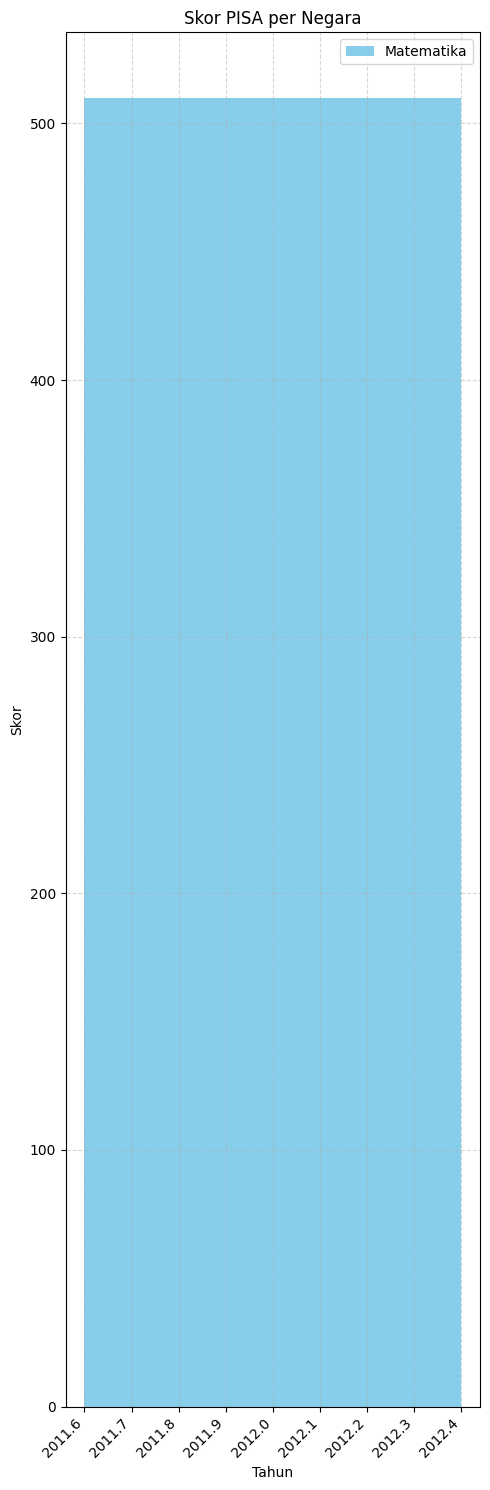

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Front_End/static/chart/api/education_data/PISA.csv")

print('Kolom yang tersedia:')
print(df)
print(df.columns.tolist())

plt.figure(figsize=(5, 15))
df_sorted = df.sort_values(by='Category', ascending=False)
plt.bar(df_sorted['Category'],df_sorted['x_maths'], color='skyblue', label='Matematika')
plt.title("Skor PISA per Negara")
plt.xlabel("Tahun")
plt.ylabel("Skor")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Kolom yang tersedia: ['Provinsi', 'Sekolah', 'Siswa', 'Mengulang', 'Putus Sekolah', 'Kepala Sekolah dan Guru(<S1)', 'Kepala Sekolah dan Guru(≥ S1)', 'Tenaga Kependidikan(SM)', 'Tenaga Kependidikan(>SM)', 'Rombongan Belajar', 'Ruang kelas(baik)', 'Ruang kelas(rusak ringan)', 'Ruang kelas(rusak sedang)', 'Ruang kelas(rusak berat)', 'Unnamed: 14']
               Provinsi  Sekolah    Siswa  Mengulang  Putus Sekolah  \
0  Prov. D.K.I. Jakarta     2224   756455       1202            869   
1      Prov. Jawa Barat    19553  4487262       4778           5675   
2     Prov. Jawa Tengah    18618  2595050       6909           2399   

   Kepala Sekolah dan Guru(<S1)  Kepala Sekolah dan Guru(≥ S1)  \
0                          1089                          38305   
1                          5007                         209252   
2                          2337                         167535   

   Tenaga Kependidikan(SM)  Tenaga Kependidikan(>SM)  Rombongan Belajar  \
0                     6967  

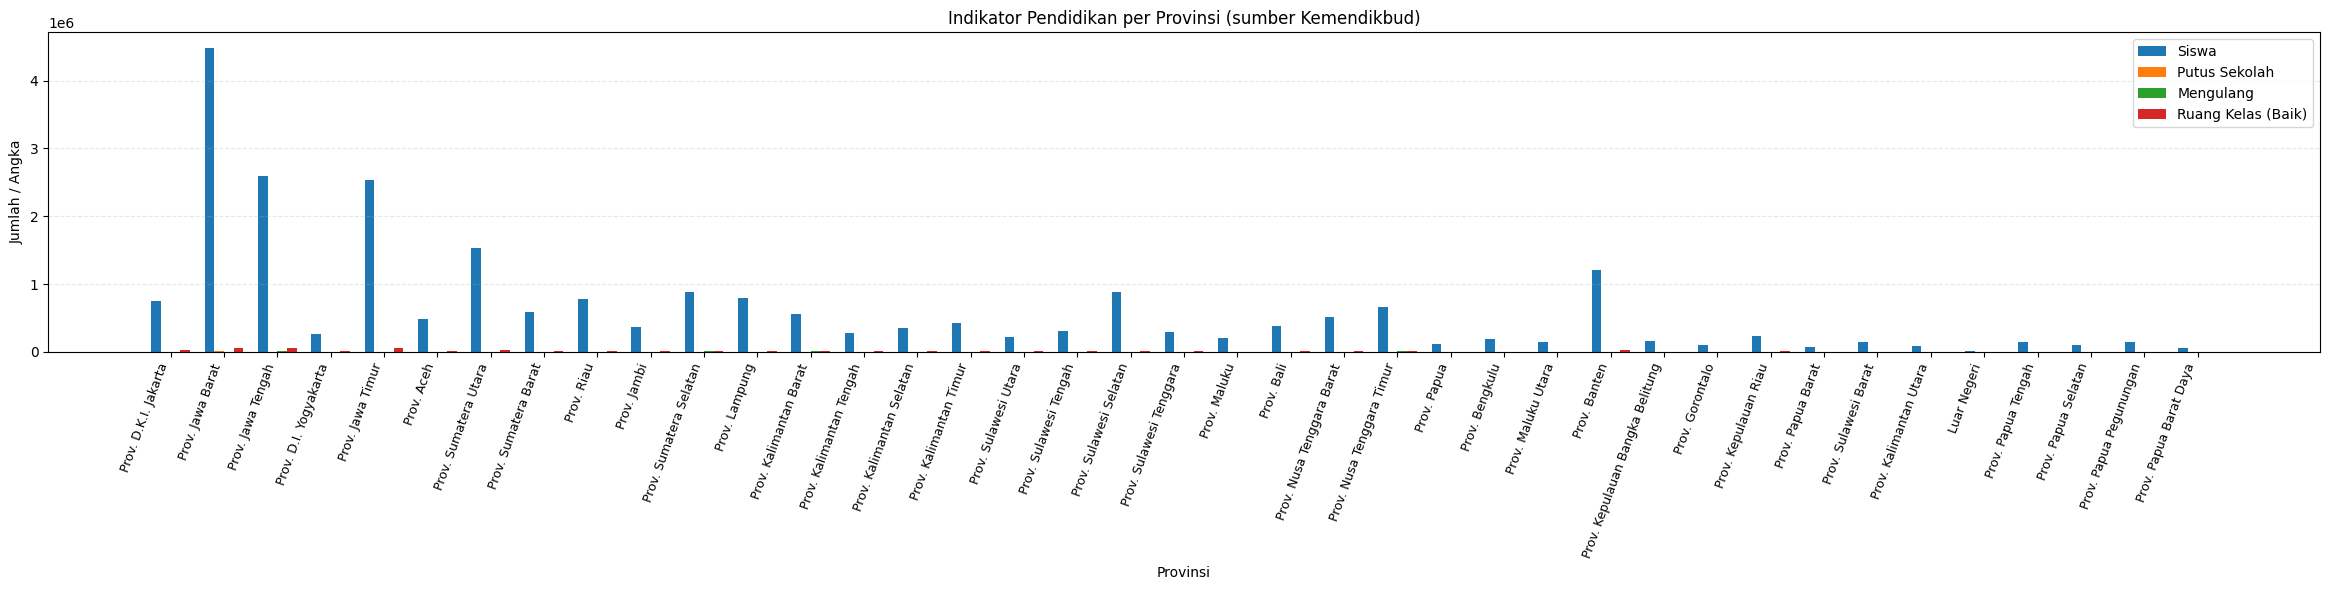

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('Front_End/static/chart/api/education_data/kelayakan-pendidikan-indonesia.csv')

print("Kolom yang tersedia:", df.columns.tolist())
print(df.head(3))

# Penyesuaian: kelayakan-pendidikan-indonesia.csv kolom-kolomnya berbeda.
# Kolom penting: 'Provinsi', 'Siswa', 'Putus Sekolah', 'Mengulang', 'Ruang kelas(ba…)'
# Ambil info provinsi dan beberapa indikator utama

prov_col = [col for col in df.columns if 'prov' in col.lower() or 'provinsi' in col.lower()]
provinsi_col = prov_col[0] if prov_col else df.columns[0]

indikator_dict = {
    'Siswa': [col for col in df.columns if 'siswa' in col.lower()],
    'Putus Sekolah': [col for col in df.columns if 'putus' in col.lower()],
    'Mengulang': [col for col in df.columns if 'mengulang' in col.lower()],
    'Ruang Kelas (Baik)': [col for col in df.columns if 'ruang kelas' in col.lower() and 'baik' in col.lower()]
}

# Pilih hanya yang ditemukan
indikator_dict = {k: v[0] for k, v in indikator_dict.items() if v}

if not indikator_dict:
    raise ValueError("Tidak menemukan indikator utama dalam kolom CSV.")

provinsi = df[provinsi_col]
n_indikator = len(indikator_dict)

plt.figure(figsize=(max(10, len(provinsi) * 0.6), 6))

bar_width = 0.18
bar_pos = range(len(provinsi))

# Plot beberapa indikator
for idx, (label, col) in enumerate(indikator_dict.items()):
    # Untuk offset agar bar tidak saling menimpa
    posisi = [i + (idx - n_indikator/2)*bar_width + bar_width/2 for i in bar_pos]
    y = pd.to_numeric(df[col], errors='coerce')
    plt.bar(posisi, y, width=bar_width, label=label)

plt.xticks(bar_pos, provinsi, rotation=70, ha='right', fontsize=9)
plt.xlabel('Provinsi')
plt.ylabel('Jumlah / Angka')
plt.title('Indikator Pendidikan per Provinsi (sumber Kemendikbud)')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()



      DATASET BERHASIL DIMUAT    

📌 Daftar Kolom Tersedia:
1. Provinsi
2. Sekolah
3. Siswa
4. Mengulang
5. Putus Sekolah
6. Kepala Sekolah dan Guru(<S1)
7. Kepala Sekolah dan Guru(≥ S1)
8. Tenaga Kependidikan(SM)
9. Tenaga Kependidikan(>SM)
10. Rombongan Belajar
11. Ruang kelas(baik)
12. Ruang kelas(rusak ringan)
13. Ruang kelas(rusak sedang)
14. Ruang kelas(rusak berat)
15. Unnamed: 14

📌 5 Baris Pertama Dataset:
                Provinsi  Sekolah    Siswa  Mengulang  Putus Sekolah  \
0   Prov. D.K.I. Jakarta     2224   756455       1202            869   
1       Prov. Jawa Barat    19553  4487262       4778           5675   
2      Prov. Jawa Tengah    18618  2595050       6909           2399   
3  Prov. D.I. Yogyakarta     1846   270610        357             75   
4       Prov. Jawa Timur    18980  2530849       4694           3327   

   Kepala Sekolah dan Guru(<S1)  Kepala Sekolah dan Guru(≥ S1)  \
0                          1089                          38305   
1              

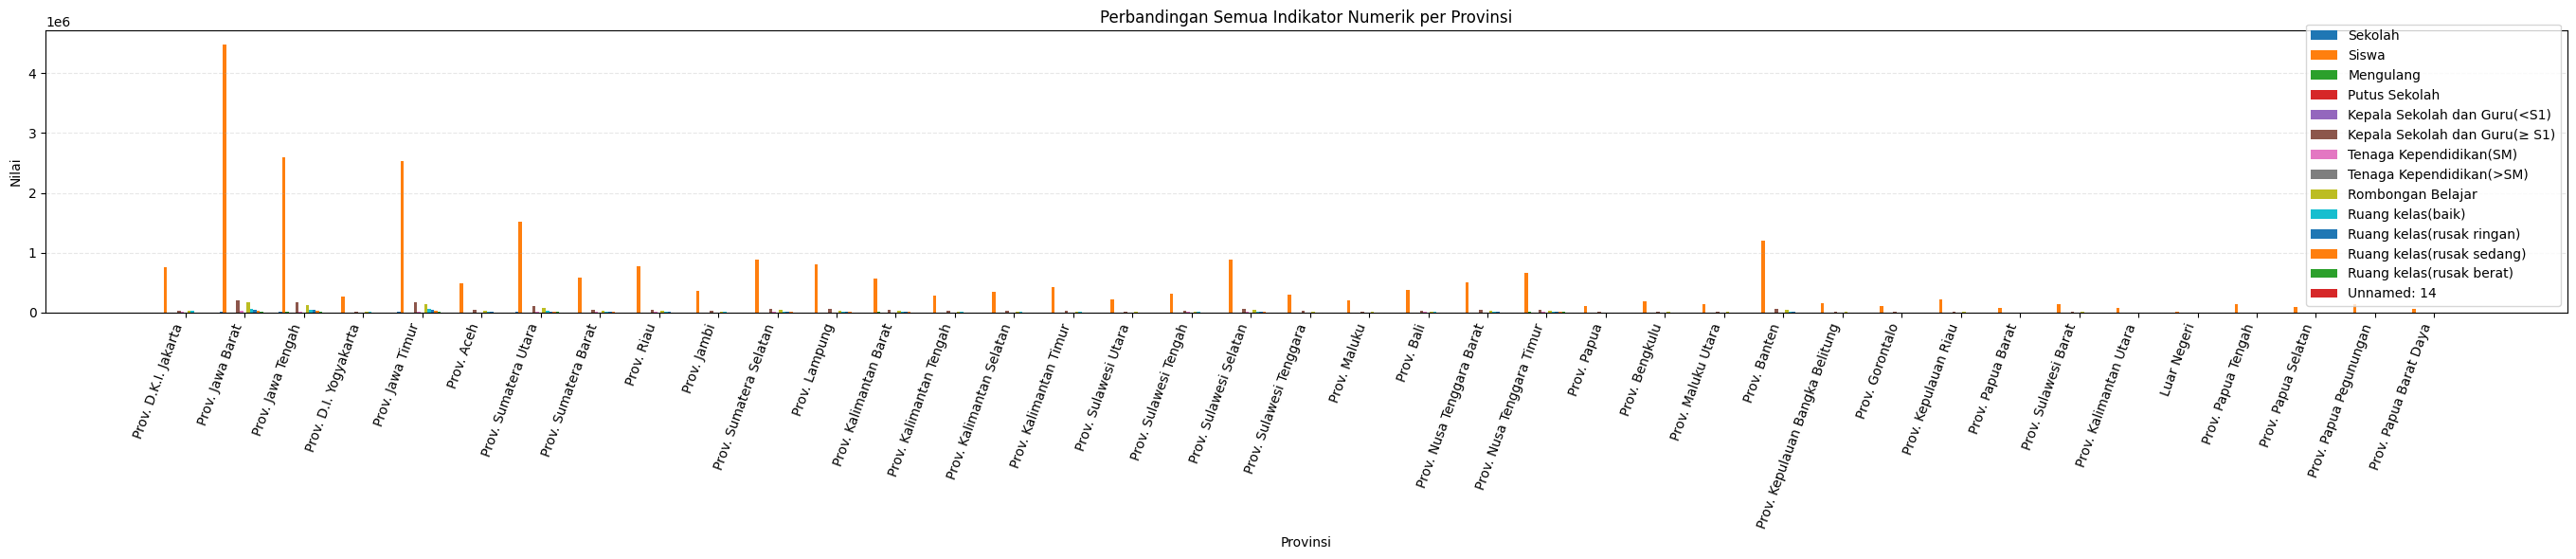


📊 Membuat visualisasi untuk setiap kolom numerik...



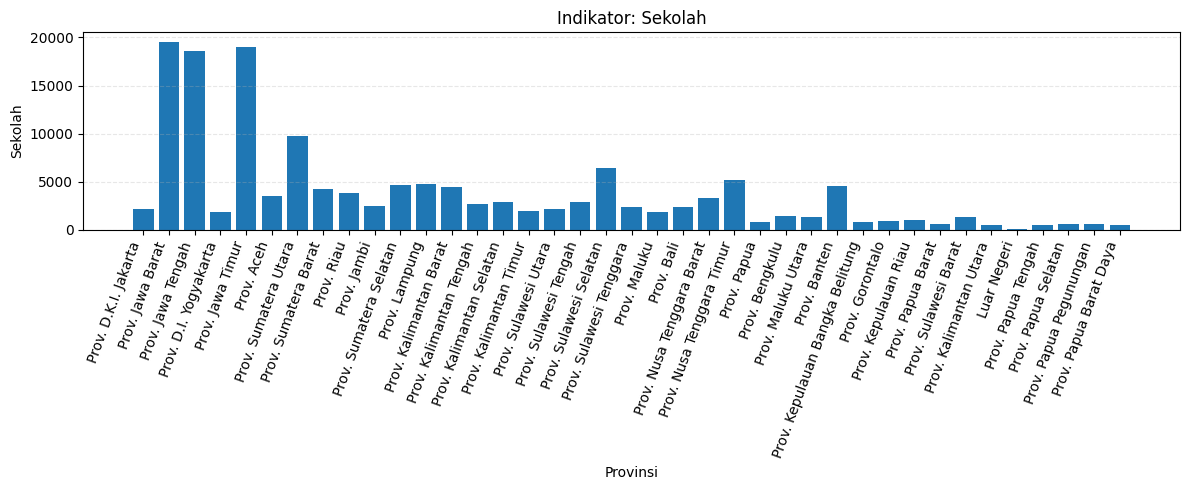

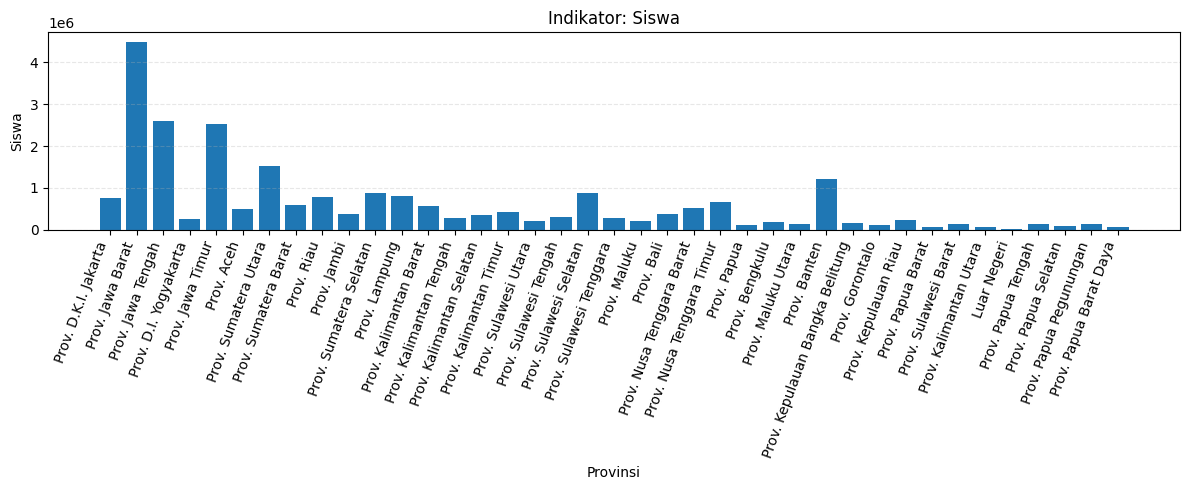

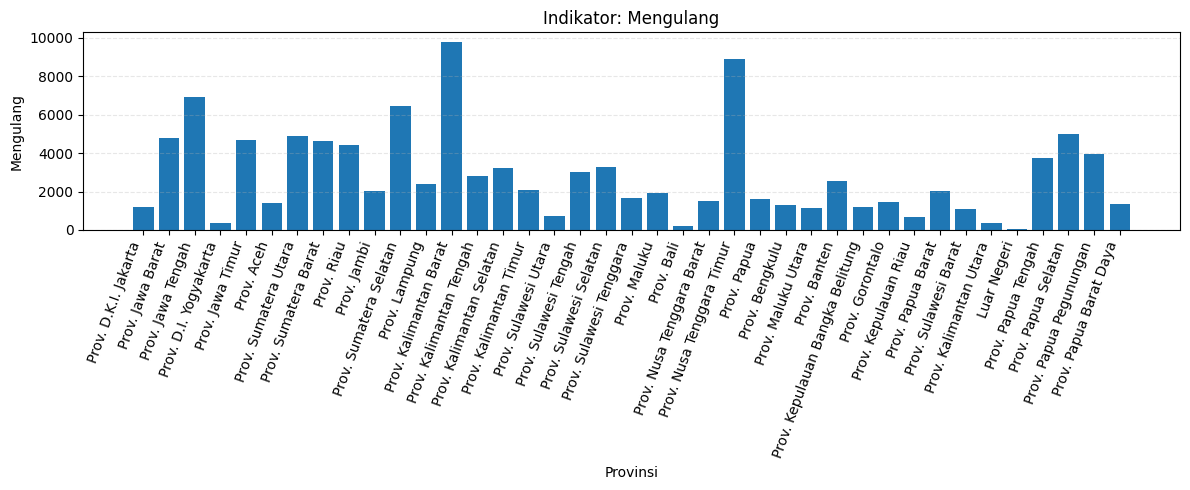

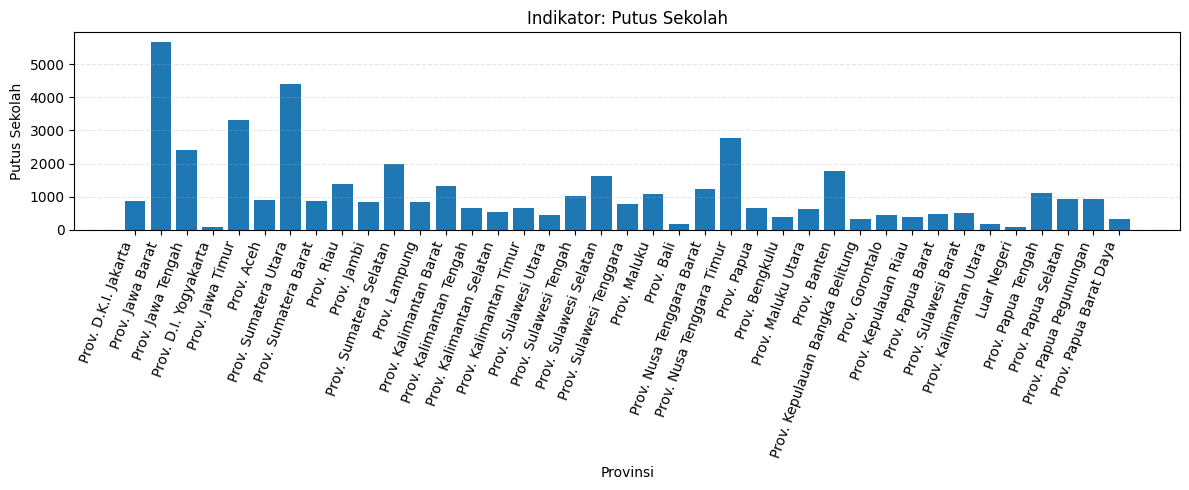

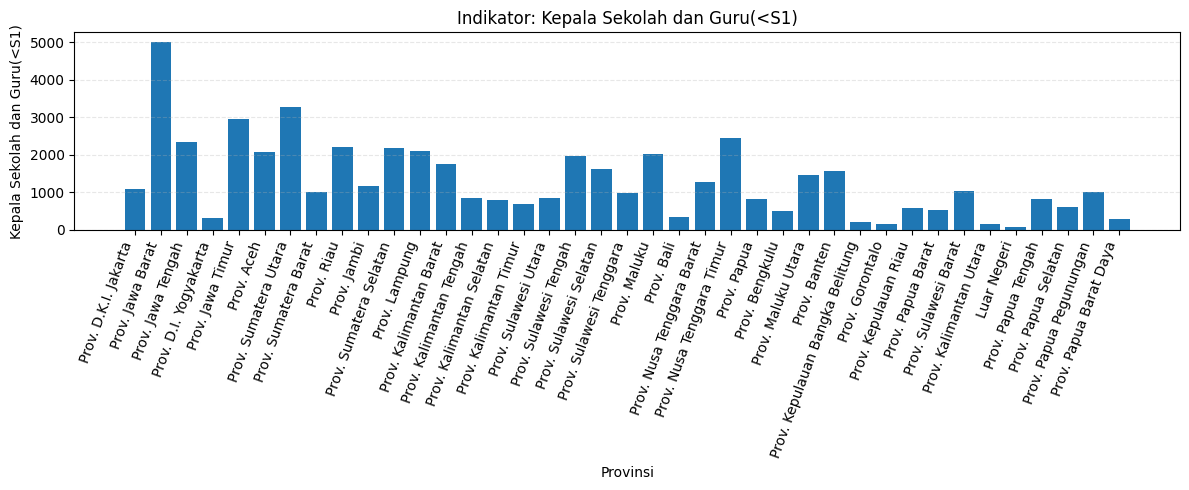

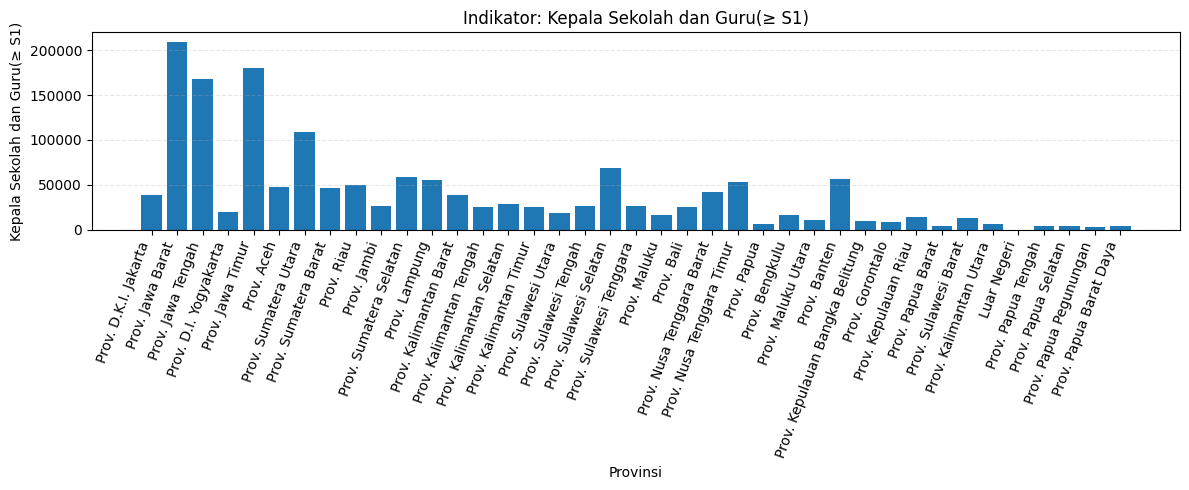

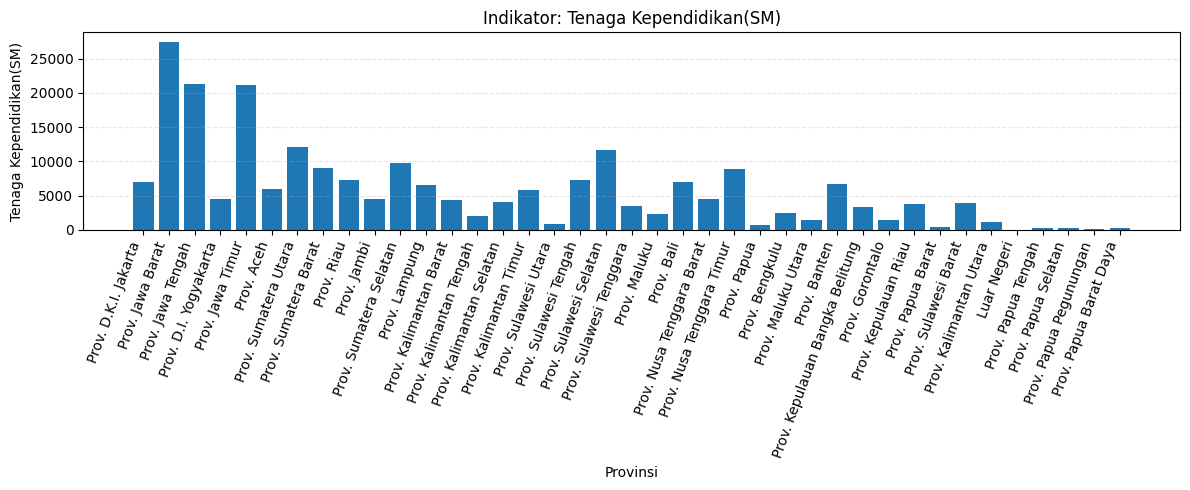

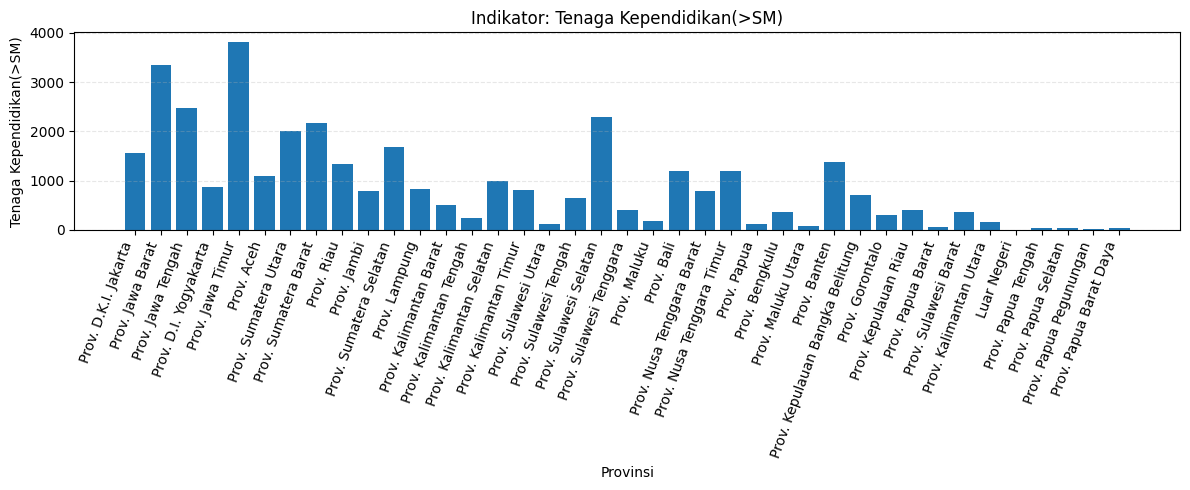

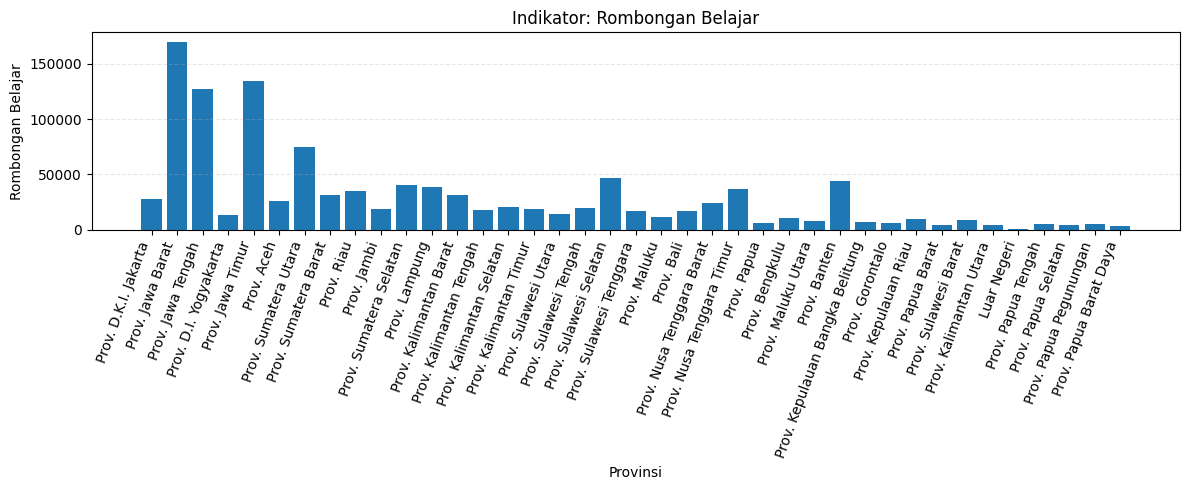

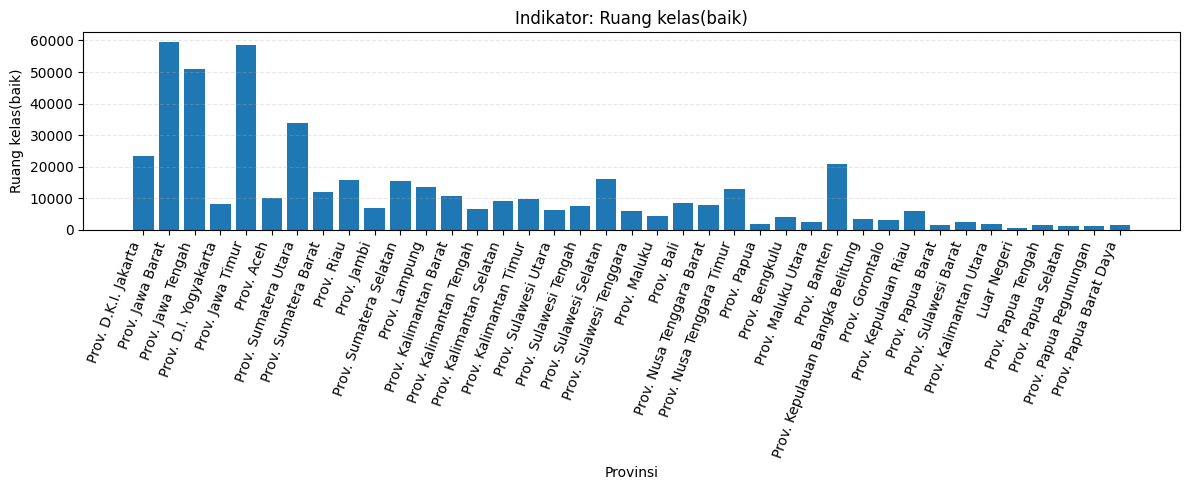

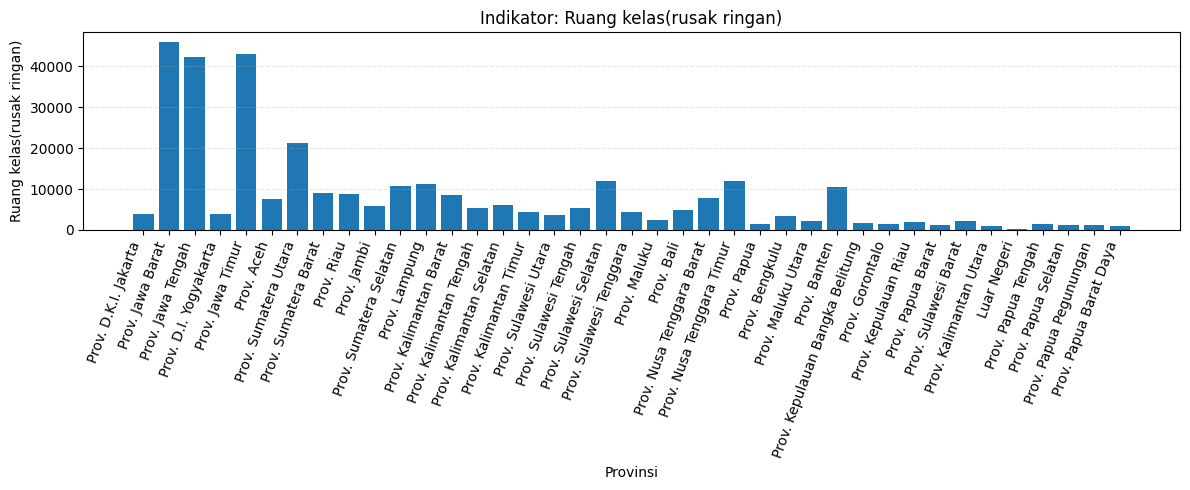

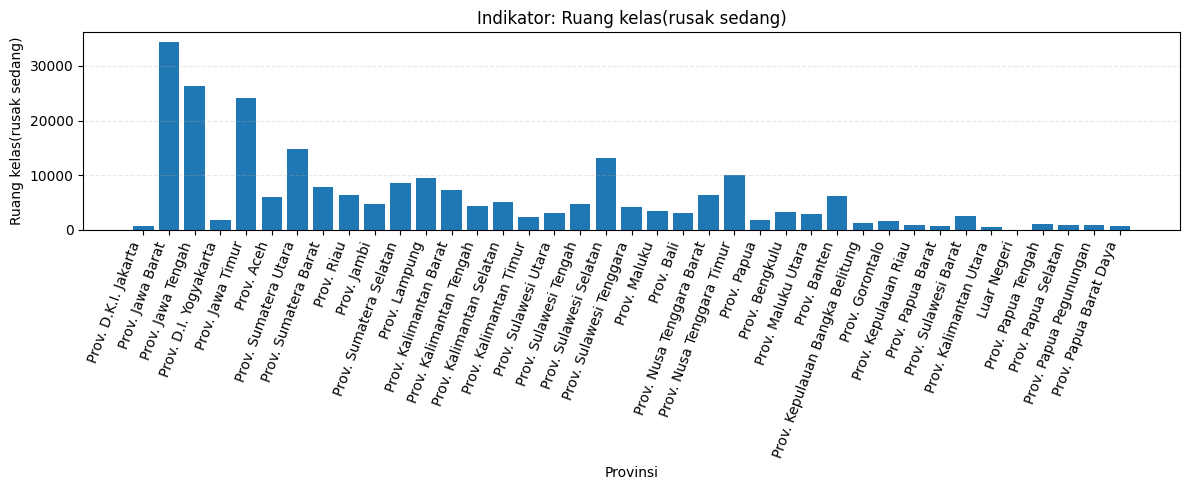

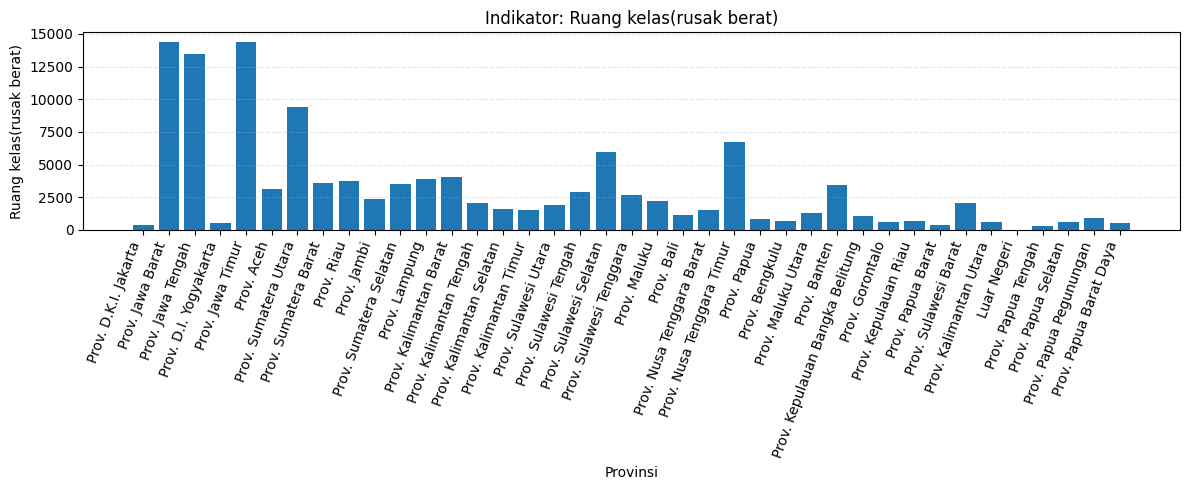

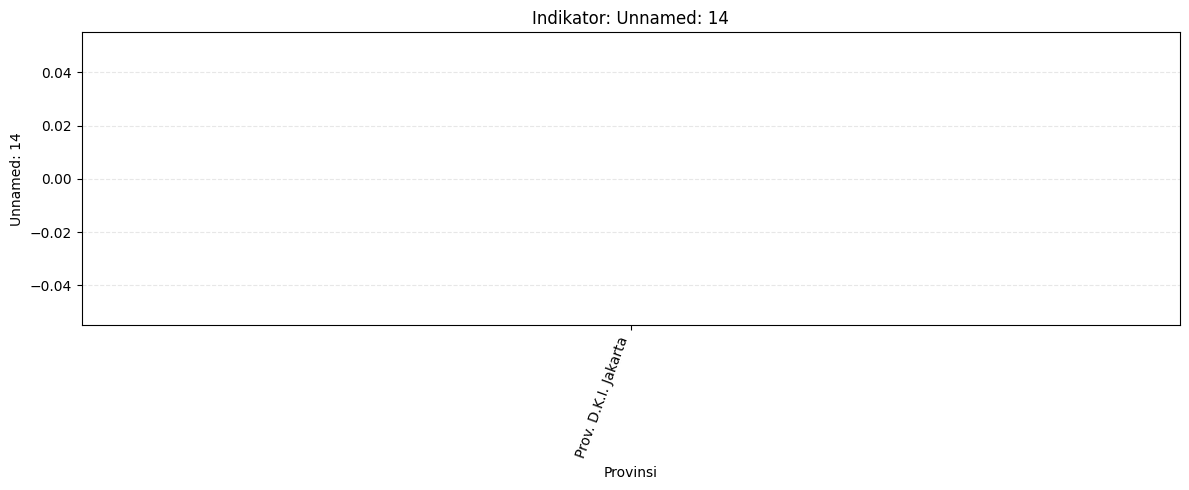


 SEMUA DATA & GRAFIK SELESAI 



In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# 1. LOAD CSV
# ===============================
file_path = "Front_End/static/chart/api/education_data/kelayakan-pendidikan-indonesia.csv"

df = pd.read_csv(file_path)

print("\n=================================")
print("      DATASET BERHASIL DIMUAT    ")
print("=================================\n")

# Tampilkan kolom
print("📌 Daftar Kolom Tersedia:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# Tampilkan sebagian data
print("\n📌 5 Baris Pertama Dataset:")
print(df.head())

# Summary statistik
print("\n📌 Statistik Deskriptif:")
print(df.describe(include='all'))


# ===============================
# 2. IDENTIFIKASI KOLOM
# ===============================
# Cari nama kolom provinsi
prov_col = [c for c in df.columns if "prov" in c.lower()]
provinsi_col = prov_col[0] if prov_col else df.columns[0]

provinsi = df[provinsi_col]

# Ambil semua kolom numerik selain provinsi
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Jika kolom numerik tidak ditemukan, coba convert otomatis
if not kolom_numerik:
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col], errors='ignore')
        except:
            pass
    kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()


print("\n📌 Kolom Numerik Ditemukan:")
print(kolom_numerik)


# ===============================
# 3. VISUALISASI MULTI-INDIKATOR
# ===============================
if len(kolom_numerik) >= 2:
    plt.figure(figsize=(max(12, len(provinsi) * 0.7), 6))

    bar_width = 0.8 / len(kolom_numerik)
    bar_pos = np.arange(len(provinsi))

    for idx, col in enumerate(kolom_numerik):
        posisi = bar_pos + (idx * bar_width)
        plt.bar(posisi, df[col], width=bar_width, label=col)

    plt.xticks(bar_pos + bar_width * len(kolom_numerik) / 2,
               provinsi, rotation=70, ha='right')

    plt.title("Perbandingan Semua Indikator Numerik per Provinsi")
    plt.xlabel("Provinsi")
    plt.ylabel("Nilai")
    plt.legend()
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.show()


# ===============================
# 4. VISUALISASI PER KOLOM (AUTO)
# ===============================
print("\n📊 Membuat visualisasi untuk setiap kolom numerik...\n")

for col in kolom_numerik:
    plt.figure(figsize=(12, 5))
    plt.bar(provinsi, df[col])
    plt.title(f"Indikator: {col}")
    plt.xlabel("Provinsi")
    plt.ylabel(col)
    plt.xticks(rotation=70, ha='right')
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.show()

print("\n===============================")
print(" SEMUA DATA & GRAFIK SELESAI ")
print("===============================\n")
